# Eksperyment: Trening od Zera na Skośnym Datasecie
## Hierarchical Sampling vs Random Sampling

Ten notatnik replikuje strukturę eksperymentu z hierarchicznym samplowaniem,
ale zamiast modelu fine-tuned/frozen używa **ResNet18 z losową inicjalizacją wag**.

**Kluczowe różnice względem notebooka z fine-tuningiem:**
- Model trenowany od zera (`weights=None`) — wszystkie warstwy trenowalne
- Dodany warunek kontrolny: **random sampling** (bez klasteryzacji), tej samej wielkości
- Silniejsza augmentacja treningowa
- SGD + momentum + CosineAnnealingLR zamiast Adam
- Więcej epok, dłuższa cierpliwość early stopping

**Pytanie badawcze:** Czy hierarchiczne samplowanie pomaga przy treningu od zera
na skośnym datasecie, i w jakim stopniu — w porównaniu do losowego subsamplingu?

### Importy

In [11]:
import os
import sys
import subprocess
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


### Konfiguracja notebooka

In [12]:
# --- SETUP ---
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", message=".*Torch was not compiled with flash attention.*")

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
SEED = 45390
PROJECT_PATH = os.path.abspath(".")
print(f"Device: {device}")

# --- KONFIGURACJA DATASETU ---
# Ustaw DATASET na jeden z poniższych kluczy.
# Skewed datasety muszą być przygotowane wcześniej przez prepare_skewed_train.py.
DATASET = "skewed_places365_alpha10"  # zmień na właściwy

DATASET_CONFIGS = {
    "skewed_imagenet1k_alpha05": {
        "dir_name":       "skewed_imagenet1k_alpha05",
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       "test",
        "split_val_test": False,
        "num_classes":    10,
        "alpha":          0.5,
    },
    "skewed_places365_alpha10": {
        "dir_name":       "skewed_places365_alpha1",
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       None,
        "split_val_test": True,
        "num_classes":    10,
        "alpha":          1.0,
    },
    "skewed_places365_alpha05": {
        "dir_name":       "skewed_places365_alpha05",
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       None,
        "split_val_test": True,
        "num_classes":    10,
        "alpha":          0.5,
    },
    "skewed_places365_alpha01": {
        "dir_name":       "skewed_places365_alpha01",
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       None,
        "split_val_test": True,
        "num_classes":    10,
        "alpha":          0.1,
    },
}

DATA_ROOT = os.path.join(PROJECT_PATH, "data")
_cfg        = DATASET_CONFIGS[DATASET]
NUM_CLASSES = _cfg["num_classes"]
DATA_PATH   = os.path.join(DATA_ROOT, _cfg["dir_name"])

print(f"Dataset : {DATASET}  (α={_cfg['alpha']})")
print(f"Klasy   : {NUM_CLASSES}")
print(f"Ścieżka : {DATA_PATH}")

# --- REPO Z PAPIERU ---
REPO_NAME = "ssl-data-curation"
REPO_URL  = "https://github.com/facebookresearch/ssl-data-curation.git"
REPO_PATH = os.path.join(PROJECT_PATH, f"{REPO_NAME}/")

# --- HIPERPARAMETRY TRENINGU OD ZERA ---
MAX_EPOCHS              = 150
EARLY_STOPPING_PATIENCE = 20    # dłuższa cierpliwość niż przy fine-tuningu
BATCH_SIZE              = 64
LR                      = 0.01
MOMENTUM                = 0.9
WEIGHT_DECAY            = 1e-4

# --- METODY SAMPLOWANIA DO PORÓWNANIA ---
# 'hierarchical_sampling' — z klasteryzacją (jak w oryginalnym papierze)
# 'random'                — losowy subsampling (baseline kontrolny)
SAMPLING_METHODS = ["hierarchical_sampling", "random"]

# --- PARAMETRY HIERARCHICZNEGO K-MEANS (DINO) ---
N_CLUSTERS_DINO   = [40, 10]
N_LEVELS_DINO     = 2
SAMPLE_SIZES_DINO = [400, 1600]

# --- EMBEDDINGI DINO: ładowanie z pliku lub ekstrakcja na żywo ---
# True  → wczytaj gotowe embeddingi z pliku .pkl (szybko, bez GPU dla ekstrakcji)
# False → oblicz embeddingi na żywo z modelu DINOv2-large
LOAD_DINO_EMBEDDINGS_FROM_PKL = True
DINO_EMBEDDINGS_PKL_PATH      = os.path.join(PROJECT_PATH, "dino_embeddings1.0_places365.pt")

print(f"Ładowanie embeddingów z pkl: {LOAD_DINO_EMBEDDINGS_FROM_PKL}")
if LOAD_DINO_EMBEDDINGS_FROM_PKL:
    print(f"Ścieżka pkl: {DINO_EMBEDDINGS_PKL_PATH}")


Device: mps
Dataset : skewed_places365_alpha10  (α=1.0)
Klasy   : 10
Ścieżka : /Users/lila/WB_Projekt/WB2_Project/data/skewed_places365_alpha1
Ładowanie embeddingów z pkl: True
Ścieżka pkl: /Users/lila/WB_Projekt/WB2_Project/dino_embeddings1.0_places365.pt


In [13]:
def setup_repo():
    if not os.path.exists(REPO_PATH):
        print(f"--- Klonowanie repozytorium {REPO_NAME}... ---")
        subprocess.run(["git", "clone", REPO_URL], check=True)
    src_path = os.path.join(REPO_PATH, "src")
    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)
    print("--- Repository paths configured ---")

setup_repo()
from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg
from src import hierarchical_sampling as hs
from other_clustering_methods import kmeans_sampling, dbscan_sampling


--- Repository paths configured ---


### Wczytanie datasetu

In [14]:
class ResnetTransform:
    """Standardowy transform do ekstrakcji cech i ewaluacji."""
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    def __call__(self, img):
        return self.transform(img)


# Augmentacja treningowa — kluczowa przy treningu od zera.
# Używana TYLKO podczas treningu modelu, nie przy ekstrakcji embeddingów.
scratch_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class DinoTransform:
    def __init__(self, processor=AutoImageProcessor.from_pretrained('facebook/dinov2-large')):
        self.processor = processor
    def __call__(self, img):
        return self.processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)


def _split_val_test(base_dataset, seed: int):
    indices = np.arange(len(base_dataset))
    v_idx, t_idx = train_test_split(
        indices, test_size=0.5, stratify=base_dataset.targets, random_state=seed
    )
    return Subset(base_dataset, v_idx), Subset(base_dataset, t_idx)


def load_datasets(cfg: dict, data_path: str, seed: int, batch_size: int = 64):
    train_dir = os.path.join(data_path, cfg["train_dir"])

    # Dwa widoki train setu:
    # - ResnetTransform: do ekstrakcji cech i samplowania
    # - DinoTransform:   do ekstrakcji embeddingów DINO
    # - scratch_train_transform: używany PODCZAS treningu modelu od zera
    train_dataset_resnet = datasets.ImageFolder(train_dir, transform=ResnetTransform())
    train_dataset_dino   = datasets.ImageFolder(train_dir, transform=DinoTransform())
    # Osobna instancja datasetu z augmentacją treningową — używana przy DataLoaderze do treningu
    train_dataset_scratch = datasets.ImageFolder(train_dir, transform=scratch_train_transform)

    if cfg["split_val_test"]:
        val_base = datasets.ImageFolder(
            os.path.join(data_path, cfg["val_dir"]), transform=ResnetTransform()
        )
        val_dataset, test_dataset = _split_val_test(val_base, seed)
    else:
        val_dataset  = datasets.ImageFolder(
            os.path.join(data_path, cfg["val_dir"]),  transform=ResnetTransform()
        )
        test_dataset = datasets.ImageFolder(
            os.path.join(data_path, cfg["test_dir"]), transform=ResnetTransform()
        )

    val_loader  = DataLoader(val_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    print(f"Train : {len(train_dataset_resnet):>6} próbek")
    print(f"Val   : {len(val_dataset):>6} próbek")
    print(f"Test  : {len(test_dataset):>6} próbek")

    # Wypisz rozkład klas (istotne przy skośnym datasecie)
    counts = np.bincount(train_dataset_resnet.targets)
    print(f"Rozkład klas — min: {counts.min()}, max: {counts.max()}, "
          f"ratio: {counts.max()/counts.min():.1f}x")

    return train_dataset_resnet, train_dataset_dino, train_dataset_scratch, val_loader, test_loader


train_dataset_resnet, train_dataset_dino, train_dataset_scratch, val_loader, test_loader = \
    load_datasets(_cfg, DATA_PATH, SEED, BATCH_SIZE)


Train :  20255 próbek
Val   :    500 próbek
Test  :    500 próbek
Rozkład klas — min: 200, max: 4993, ratio: 25.0x


### Funkcje pomocnicze

In [15]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def get_scratch_model(num_classes: int, device: torch.device) -> nn.Module:
    """
    ResNet18 z LOSOWO ZAINICJOWANYMI wagami.
    Wszystkie parametry są trenowalne — brak zamrożonych warstw.
    """
    model = models.resnet18(weights=None)  # weights=None → brak pretrainingu
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


# --- Ekstrakcja embeddingów DINO (do klasteryzacji) ---

def get_dino_embeddings(dataset, batch_size=128):
    """Oblicza embeddingi DINOv2-large na żywo z datasetu."""
    extractor = AutoModel.from_pretrained("facebook/dinov2-large")
    extractor.eval().to(device)
    all_embeddings = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        for imgs, _ in tqdm(
            DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0),
            desc="DINO feature extraction",
        ):
            emb = extractor(imgs.to(device)).last_hidden_state[:, 0, :]
            all_embeddings.append(emb.cpu())
    return torch.cat(all_embeddings).to(device)


def load_dino_embeddings_from_pkl(pkl_path: str, device: torch.device) -> torch.Tensor:
    """Wczytuje wcześniej obliczone embeddingi DINO z pliku .pkl."""
    import pickle
    print(f"Wczytywanie embeddingów z: {pkl_path}")
    data = torch.load(pkl_path, map_location=device)
    # Obsługa zarówno samego tensora, jak i słownika {"embeddings": tensor}
    if isinstance(data, dict):
        tensor = data.get("embeddings", data.get("dino_embeddings", next(iter(data.values()))))
    else:
        tensor = data
    if not isinstance(tensor, torch.Tensor):
        tensor = torch.tensor(tensor)
    print(f"Wczytano embeddingi: shape={tuple(tensor.shape)}, dtype={tensor.dtype}")
    return tensor.float().to(device)


def plot_training_curve(train_losses, val_losses, title="Training Curve"):
    plt.figure(figsize=(8, 5))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, marker="o", markersize=3, label="Train Loss")
    plt.plot(epochs, val_losses,   marker="s", markersize=3, label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Pętla treningowa

In [16]:
def train_model(
    model, criterion, optimizer, scheduler,
    train_loader, val_loader, test_loader,
    device, title,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    epoch_tqdm=True,
):
    print(f"\n[TRENING] Start: {title}")
    use_amp = device.type == "cuda"
    scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)

    train_losses, val_losses = [], []
    best_val_loss    = float("inf")
    best_state       = {k: v.clone() for k, v in model.state_dict().items()}
    patience_counter = 0

    epoch_iter = tqdm(range(max_epochs), desc="Epochs") if epoch_tqdm else range(max_epochs)

    for epoch in epoch_iter:
        # --- trening ---
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        # --- walidacja ---
        model.eval()
        val_loss = 0.0
        with torch.inference_mode():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                val_loss += criterion(model(imgs), labels).item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step()

        # --- early stopping ---
        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping przy epoce {epoch + 1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    # --- ewaluacja końcowa ---
    results = {}
    with torch.inference_mode():
        for loader, split_name in [(val_loader, "Validation"), (test_loader, "Test")]:
            correct, total = 0, 0
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                _, predicted = torch.max(model(imgs), 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()
            acc = 100 * correct / total
            results[split_name] = acc
            print(f"[RESULT] {title} — {split_name} Accuracy: {acc:.2f}%")

    return results["Test"], train_losses, val_losses


### Ekstrakcja cech i hierarchiczny k-means

In [17]:
print("\n--- Embeddingi DINO ---")
set_seed(SEED)

if LOAD_DINO_EMBEDDINGS_FROM_PKL:
    dino_embeddings = torch.load(DINO_EMBEDDINGS_PKL_PATH, map_location="cpu").float()
else:
    dino_embeddings = get_dino_embeddings(train_dataset_dino).float()
    # Opcjonalnie: zapisz obliczone embeddingi do pliku, by móc je wczytać później
    # import pickle
    # with open(DINO_EMBEDDINGS_PKL_PATH, "wb") as f:
    #     pickle.dump(dino_embeddings.cpu(), f)
    # print(f"Zapisano embeddingi do: {DINO_EMBEDDINGS_PKL_PATH}")

print("\n--- Hierarchiczny k-means (DINO) ---")
clusters_dino = hkmg.hierarchical_kmeans_with_resampling(
    data=dino_embeddings,
    n_clusters=N_CLUSTERS_DINO,
    n_levels=N_LEVELS_DINO,
    sample_sizes=SAMPLE_SIZES_DINO,
    verbose=False,
)
cl_dino = HierarchicalCluster.from_dict(clusters_dino)

print("Klasteryzacja zakończona.")



--- Embeddingi DINO ---

--- Hierarchiczny k-means (DINO) ---
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:00<00:00, 10.58it/s]
Klasteryzacja zakończona.


### Główna pętla eksperymentu

Dla każdego procentu danych i każdej metody embeddingów porównujemy:
- **hierarchical_sampling** — subsampling przez klasteryzację (jak w papierze)
- **random** — losowy subsampling tej samej wielkości (baseline kontrolny)

Model w obu przypadkach: ResNet50 z losową inicjalizacją wag.

Eksperyment: Hierarchical Sampling vs Random Sampling | Model od Zera
Dataset: skewed_places365_alpha10  (α=1.0)

Embeddings: Dino | Subset: 50% (10127 próbek)
  Metoda samplowania: hierarchical_sampling
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1179.40it/s]

[TRENING] Start: Dino | hierarchical_sampling | 50%


Epochs:  57%|█████▋    | 86/150 [10:47:50<8:02:06, 451.98s/it]

Early stopping przy epoce 87


[RESULT] Dino | hierarchical_sampling | 50% — Validation Accuracy: 73.00%
[RESULT] Dino | hierarchical_sampling | 50% — Test Accuracy: 72.40%


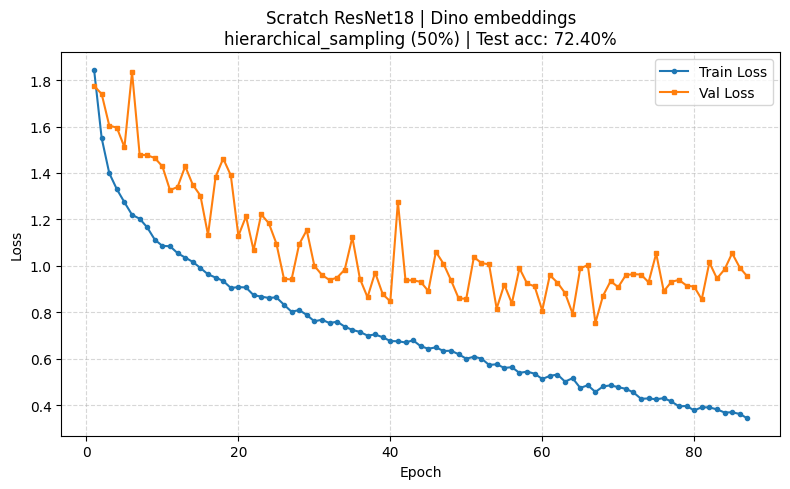

  Zapisano wyniki (scratch_results0.5.pkl)
  Metoda samplowania: random

[TRENING] Start: Dino | random | 50%


Epochs:  47%|████▋     | 70/150 [7:38:55<8:44:28, 393.36s/it] 

Early stopping przy epoce 71


[RESULT] Dino | random | 50% — Validation Accuracy: 69.20%
[RESULT] Dino | random | 50% — Test Accuracy: 67.60%


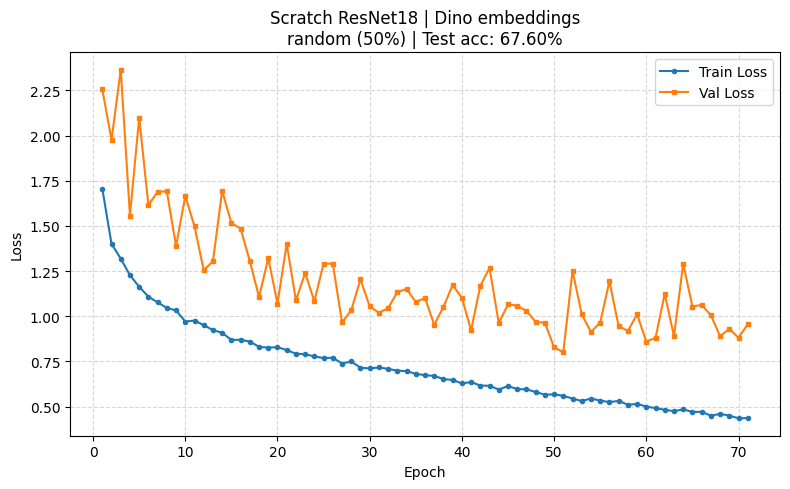

  Zapisano wyniki (scratch_results0.5.pkl)

Embeddings: Dino | Subset: 70% (14178 próbek)
  Metoda samplowania: hierarchical_sampling
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 3953.91it/s]

[TRENING] Start: Dino | hierarchical_sampling | 70%


Epochs:  43%|████▎     | 64/150 [10:39:11<14:18:54, 599.24s/it]

Early stopping przy epoce 65


[RESULT] Dino | hierarchical_sampling | 70% — Validation Accuracy: 71.00%
[RESULT] Dino | hierarchical_sampling | 70% — Test Accuracy: 70.60%


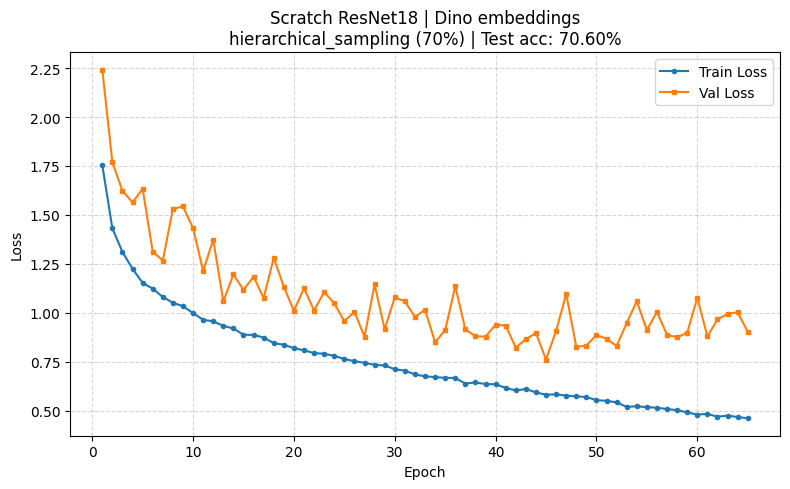

  Zapisano wyniki (scratch_results0.7.pkl)
  Metoda samplowania: random

[TRENING] Start: Dino | random | 70%


Epochs:  39%|███▉      | 59/150 [9:07:14<14:04:03, 556.52s/it]

Early stopping przy epoce 60


[RESULT] Dino | random | 70% — Validation Accuracy: 70.20%
[RESULT] Dino | random | 70% — Test Accuracy: 69.40%


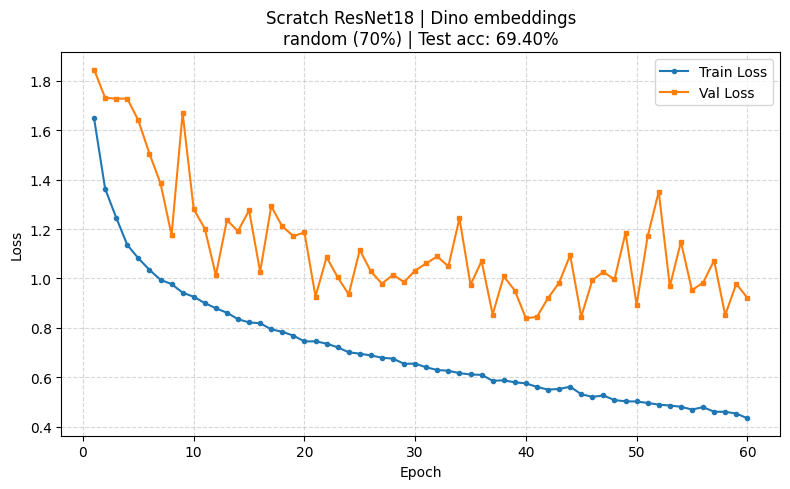

  Zapisano wyniki (scratch_results0.7.pkl)

Wszystkie eksperymenty zakończone.
         sampling_method embeddings percentage  test_accuracy
0  hierarchical_sampling       Dino        50%           72.4
1                 random       Dino        50%           67.6
2  hierarchical_sampling       Dino        70%           70.6
3                 random       Dino        70%           69.4


In [18]:
print("Eksperyment: Hierarchical Sampling vs Random Sampling | Model od Zera")
print(f"Dataset: {DATASET}  (α={_cfg['alpha']})")
print("="*60)

percentages = [0.5, 0.7]
rng_random = np.random.default_rng(SEED)

results_df = pd.DataFrame(
    columns=["sampling_method", "embeddings", "percentage", "test_accuracy", "train_losses", "val_losses"]
)
sampling_log = pd.DataFrame(columns=["sampling_method", "embeddings", "percentage", "subset"])

for embedding_name, cl_struct in [
    ("Dino", cl_dino)
]:
    for p in percentages:
        label       = f"{int(p * 100)}%"
        target_size = int(len(train_dataset_scratch) * p)
        print(f"\n{'='*60}")
        print(f"Embeddings: {embedding_name} | Subset: {label} ({target_size} próbek)")

        for sampling_method in SAMPLING_METHODS:
            print(f"  Metoda samplowania: {sampling_method}")

            if sampling_method == "hierarchical_sampling":
                idx = hs.hierarchical_sampling(cl_struct, target_size=target_size)
            elif sampling_method == "random":
                idx = rng_random.choice(
                    len(train_dataset_scratch), size=target_size, replace=False
                ).tolist()

            current_ds = Subset(train_dataset_scratch, idx)

            sampling_log.loc[len(sampling_log)] = {
                "sampling_method": sampling_method,
                "embeddings":      embedding_name,
                "percentage":      label,
                "subset":          current_ds,
            }

            # --- model od zera ---
            set_seed(SEED)
            model     = get_scratch_model(NUM_CLASSES, device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.SGD(
                model.parameters(),
                lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY,
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=MAX_EPOCHS, eta_min=1e-5
            )

            train_loader_current = DataLoader(
                current_ds, batch_size=BATCH_SIZE, shuffle=True,
                num_workers=0, generator=torch.Generator().manual_seed(SEED)
            )

            test_acc, train_losses, val_losses = train_model(
                model, criterion, optimizer, scheduler,
                train_loader_current, val_loader, test_loader,
                device,
                title=f"{embedding_name} | {sampling_method} | {label}",
                max_epochs=MAX_EPOCHS,
                patience=EARLY_STOPPING_PATIENCE,
                epoch_tqdm=True,
            )

            plot_training_curve(
                train_losses, val_losses,
                title=(
                    f"Scratch ResNet18 | {embedding_name} embeddings\n"
                    f"{sampling_method} ({label}) | Test acc: {test_acc:.2f}%"
                ),
            )

            results_df.loc[len(results_df)] = {
                "sampling_method": sampling_method,
                "embeddings":      embedding_name,
                "percentage":      label,
                "test_accuracy":   test_acc,
                "train_losses":    train_losses,
                "val_losses":      val_losses,
            }

            # Zapisz po każdym runie — Colab może się wyłączyć w połowie
            results_df.to_pickle(f"scratch_results{p}.pkl")
            print(f"  Zapisano wyniki (scratch_results{p}.pkl)")

print("\nWszystkie eksperymenty zakończone.")
print(results_df[["sampling_method", "embeddings", "percentage", "test_accuracy"]])

### Wizualizacja rozkładu klas w podzbiorach

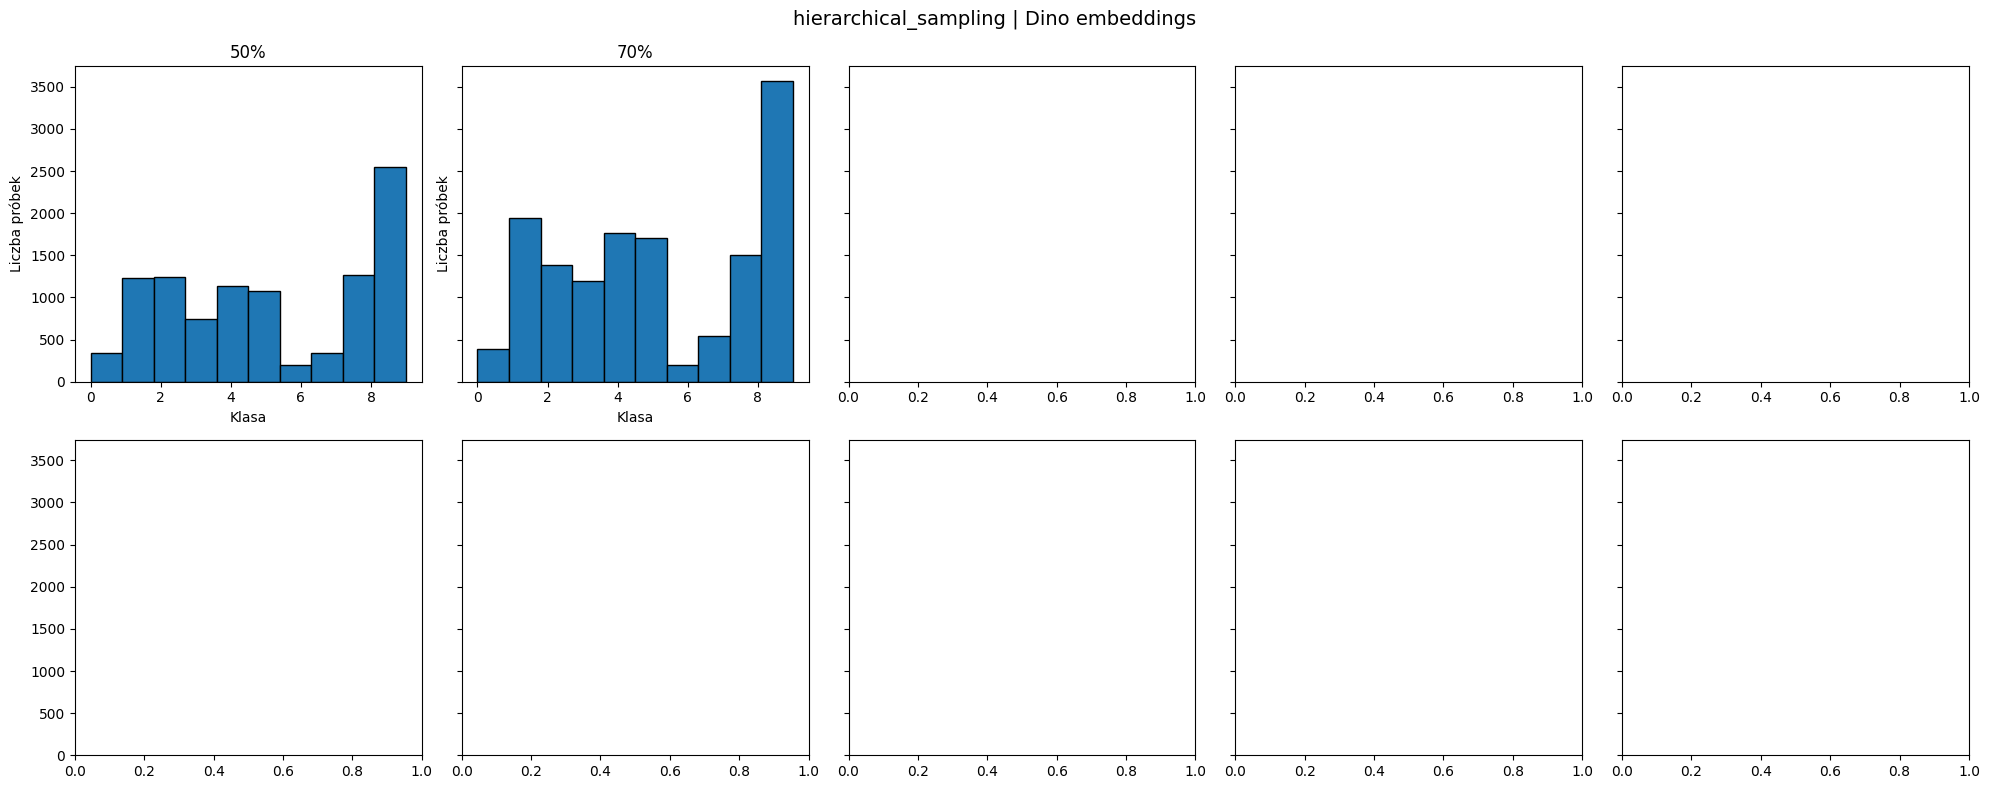

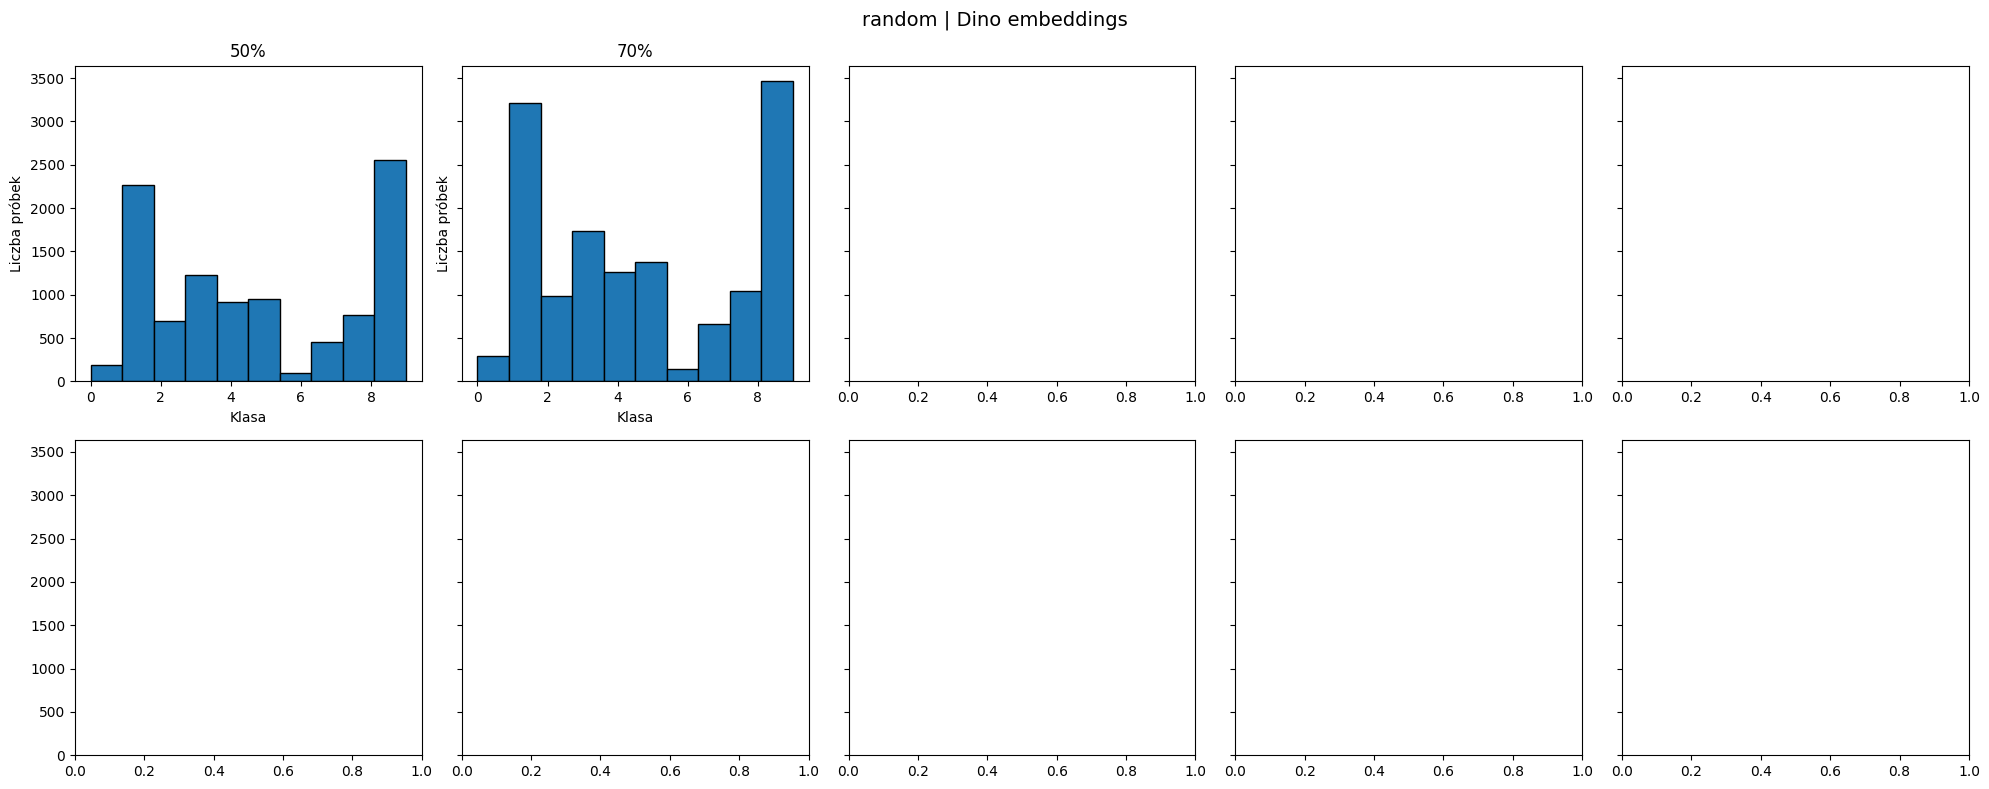

In [19]:
for method in sampling_log["sampling_method"].unique():
    for emb in sampling_log["embeddings"].unique():
        mask = (
            (sampling_log["sampling_method"] == method) &
            (sampling_log["embeddings"] == emb)
        )
        rows = sampling_log[mask].reset_index(drop=True)
        if rows.empty:
            continue

        fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
        fig.suptitle(f"{method} | {emb} embeddings", fontsize=14)
        axes = axes.flatten()

        for i, (_, row) in enumerate(rows.iterrows()):
            ds = row["subset"]
            labels = (
                [ds.dataset.targets[j] for j in ds.indices]
                if isinstance(ds, Subset) else ds.targets
            )
            axes[i].hist(labels, bins=NUM_CLASSES, edgecolor="black")
            axes[i].set_title(row["percentage"])
            axes[i].set_xlabel("Klasa")
            axes[i].set_ylabel("Liczba próbek")

        plt.tight_layout()
        plt.show()


### Wykres wyników końcowych

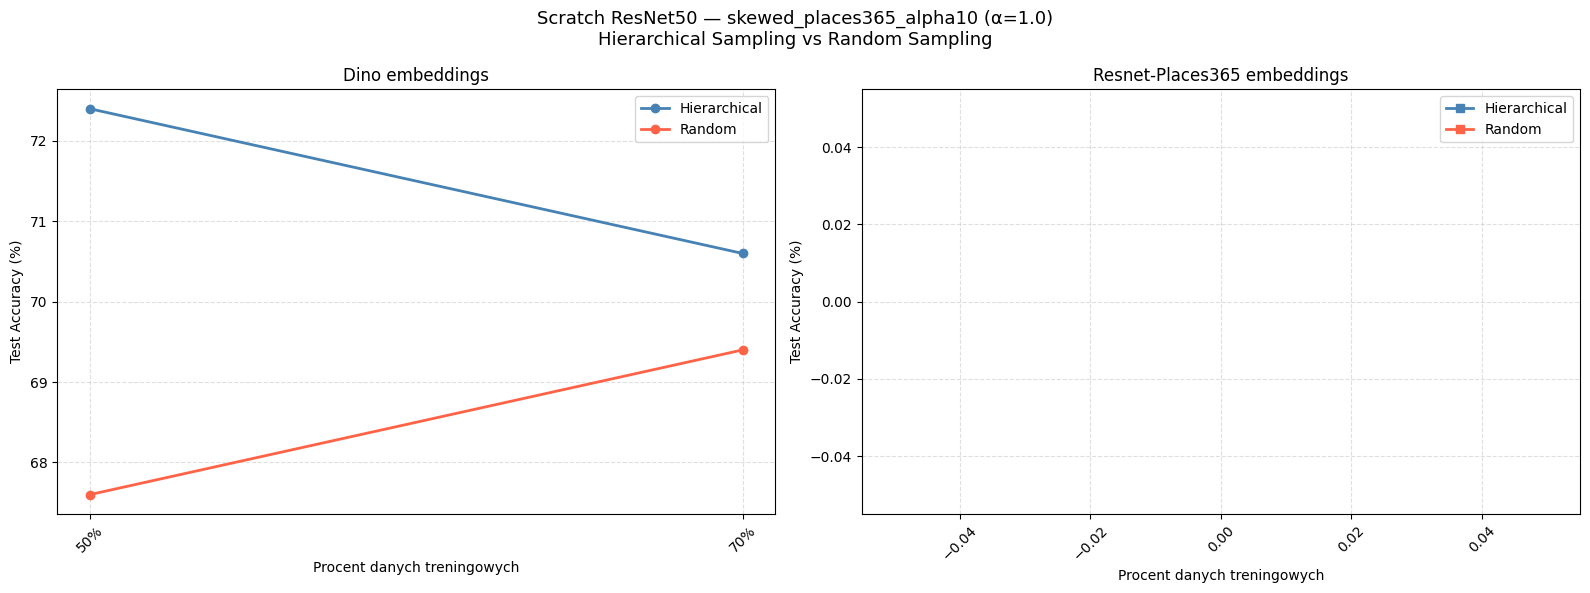

In [23]:
    # Wczytaj zapisane wyniki (jeśli notatnik jest uruchamiany ponownie)
    # results_df = pd.read_pickle("scratch_results.pkl")
for p in percentages:
        results_df = pd.read_pickle(f"scratch_results{p}.pkl")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"Scratch ResNet50 — {DATASET} (α={_cfg['alpha']})\n"
        "Hierarchical Sampling vs Random Sampling",
        fontsize=13,
    )

    colors = {"hierarchical_sampling": "steelblue", "random": "tomato"}
    markers = {"Dino": "o", "Resnet-Places365": "s"}
    pct_order = [f"{int(p*100)}%" for p in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]]

    for ax_idx, emb_name in enumerate(["Dino", "Resnet-Places365"]):
        ax = axes[ax_idx]
        for method in ["hierarchical_sampling", "random"]:
            sub = results_df[
                (results_df["embeddings"] == emb_name) &
                (results_df["sampling_method"] == method)
            ].copy()
            sub["pct_order"] = sub["percentage"].apply(lambda x: pct_order.index(x))
            sub = sub.sort_values("pct_order")

            # Dodaj punkt 100% dla random (identyczny jak hierarchical przy 100%)
            if method == "random":
                full = results_df[
                    (results_df["embeddings"] == emb_name) &
                    (results_df["sampling_method"] == "hierarchical_sampling") &
                    (results_df["percentage"] == "100%")
                ]
                if not full.empty:
                    sub = pd.concat([sub, full.assign(sampling_method="random")], ignore_index=True)
                    sub["pct_order"] = sub["percentage"].apply(lambda x: pct_order.index(x))
                    sub = sub.sort_values("pct_order")

            label = "Hierarchical" if method == "hierarchical_sampling" else "Random"
            ax.plot(
                sub["percentage"], sub["test_accuracy"].astype(float),
                marker=markers[emb_name], linewidth=2,
                color=colors[method], label=label,
            )

        # Linia bazowa: 100% danych
        full_acc = results_df[
            (results_df["embeddings"] == emb_name) &
            (results_df["sampling_method"] == "hierarchical_sampling") &
            (results_df["percentage"] == "100%")
        ]["test_accuracy"]
        if not full_acc.empty:
            ax.axhline(
                y=float(full_acc.values[0]), linestyle='--', color='gray', alpha=0.6,
                label=f"100% danych ({float(full_acc.values[0]):.1f}%)"
            )

        ax.set_xlabel("Procent danych treningowych")
        ax.set_ylabel("Test Accuracy (%)")
        ax.set_title(f"{emb_name} embeddings")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig("scratch_results.png", dpi=150)
    plt.show()
